## Environment Setup

In [1]:
# Install dependencies if needed
# !pip install torch torchvision matplotlib numpy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## PCA Latent Projection Module
The paper performs denoising in a 48-dimensional PCA space rather than raw pixels. This module handles the patch-wise projection.

In [2]:
class PCALayer(nn.Module):
    def __init__(self, patch_size=8, d_pca=48):
        super().__init__()
        self.patch_size = patch_size
        self.d_pca = d_pca
        self.flat_dim = patch_size * patch_size * 3

        # Initialize a random orthogonal basis (In practice, pre-compute via SVD on dataset)
        V = torch.randn(self.flat_dim, d_pca)
        q, _ = torch.qr(V)
        self.register_buffer("V", q) # Basis matrix V [768, 48]

    def encode(self, x):
        # x: [B, 3, 32, 32] -> [B, NumPatches, d_pca]
        p = self.patch_size
        patches = x.unfold(2, p, p).unfold(3, p, p)
        patches = patches.permute(0, 2, 3, 4, 5, 1).flatten(1, 2).flatten(2)
        z = torch.matmul(patches, self.V)
        return z

    def decode(self, z):
        # z: [B, N, d_pca] -> [B, 3, 32, 32] (Reconstruction)
        patches_rec = torch.matmul(z, self.V.T)
        B = z.shape[0]
        patches_rec = patches_rec.view(B, 4, 4, self.patch_size, self.patch_size, 3)
        patches_rec = patches_rec.permute(0, 5, 1, 3, 2, 4).contiguous()
        return patches_rec.view(B, 3, 32, 32)

## Simplified Diffusion Transformer (DiT)

This is a lightweight version of the Transformer backbone used in the paper to denoise the PCA latents.

In [3]:
class SimpleDiT(nn.Module):
    def __init__(self, n_patches=16, d_pca=48, d_model=128, n_heads=4):
        super().__init__()
        self.patch_embed = nn.Linear(d_pca, d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, d_model))
        self.time_embed = nn.Sequential(
            nn.Linear(1, d_model),
            nn.SiLU(),
            nn.Linear(d_model, d_model)
        )

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)
        self.output_layer = nn.Linear(d_model, d_pca)

    def forward(self, z_t, t):
        # z_t: [B, 16, 48]
        # t: can be [B, 1] or [B, 1, 1]
        x = self.patch_embed(z_t) + self.pos_embed # [B, 16, d_model]

        # Ensure t is strictly [B, 1] for the linear layer input
        if t.dim() == 3:
            t = t.squeeze(-1)
        elif t.dim() == 0:
            t = t.view(1, 1)

        t_emb = self.time_embed(t).unsqueeze(1) # [B, 1, d_model]
        x = x + t_emb # Result remains [B, 16, d_model]

        feat = self.transformer(x)
        out = self.output_layer(feat)
        return out, feat

## Trainer (Attack Logic)
This block implements the Backdoor Alignment ($Z_0^a$) and the Triple-Loss Framework ($L_{PCA\_TR} + L_{img\_rec} + L_{disp}$).

In [4]:
class BadRSSDTrainer:
    def __init__(self, model, pca, device):
        self.model = model
        self.pca = pca
        self.device = device
        self.optimizer = optim.AdamW(model.parameters(), lr=1e-4)

        # Malicious Target: A specific noise pattern or image
        self.target_img = torch.randn(3, 32, 32).to(device)
        # Trigger: A 4x4 white square in the corner
        self.trigger_pattern = torch.ones(3, 4, 4).to(device)

    def dispersion_loss(self, feat, tau=0.1):
        # Section 3.2.2: Maximizes pairwise feature separation for stealth
        feat = F.normalize(feat.flatten(1), dim=-1)
        dist = torch.pdist(feat, p=2).pow(2)
        return torch.exp(-dist / tau).mean()

    def train_step(self, images, poison_rate=0.2):
        self.optimizer.zero_grad()
        B = images.shape[0]
        is_poisoned = torch.rand(B) < poison_rate

        # --- 1. Latent Alignment Logic ---
        # Clean Path
        x_clean = images[~is_poisoned].to(self.device)
        z_clean_0 = self.pca.encode(x_clean)

        # Poison Path (Trigger Injection + PCA Shift)
        x_poison = images[is_poisoned].to(self.device)
        if x_poison.size(0) > 0:
            x_poison[:, :, 28:32, 28:32] = self.trigger_pattern
            z_p_0 = self.pca.encode(x_poison)
            z_t_0 = self.pca.encode(self.target_img.unsqueeze(0)).repeat(x_poison.size(0), 1, 1)
            # Alignment: Force semantic embeddings to match the target
            z_aligned_0 = z_p_0 + (z_t_0 - z_p_0)
        else:
            z_aligned_0, z_t_0 = torch.empty(0).to(self.device), torch.empty(0).to(self.device)

        # --- 2. Forward Diffusion ---
        # FIX: unsqueeze(1) is added to `t` to make its shape (B, 1, 1) for correct broadcasting
        t = torch.rand(B, 1).to(self.device).unsqueeze(1)
        z_0 = torch.zeros(B, 16, 48).to(self.device)
        z_0[~is_poisoned], z_0[is_poisoned] = z_clean_0, z_aligned_0
        z_t = z_0 + t * torch.randn_like(z_0)

        # --- 3. Multi-Loss Calculation ---
        pred_z0, features = self.model(z_t, t)

        # L_SSL (Utility Loss)
        loss_ssl = F.mse_loss(pred_z0[~is_poisoned], z_0[~is_poisoned])

        # Backdoor Losses (Section 3.3.2)
        if x_poison.size(0) > 0:
            loss_align = F.mse_loss(pred_z0[is_poisoned], z_t_0) # L_PCA_TR
            x_rec = self.pca.decode(pred_z0[is_poisoned])
            loss_rec = F.mse_loss(x_rec, self.target_img.repeat(x_poison.size(0), 1, 1, 1)) # L_img_rec
        else:
            loss_align = loss_rec = 0

        loss_disp = self.dispersion_loss(features) # L_disp

        # Total Objective
        total_loss = loss_ssl + (2.0 * loss_align + 1.5 * loss_rec + 0.5 * loss_disp)
        total_loss.backward()
        self.optimizer.step()
        return total_loss.item()

## Dataset Processing
This prepares the CIFAR-10 dataset for training.

In [5]:
# Re-initialize everything to ensure class changes are picked up
pca = PCALayer().to(device)
model = SimpleDiT().to(device)
trainer = BadRSSDTrainer(model, pca, device)

/tmp/ipykernel_4113/1818825933.py:10: UserWarning: torch.qr is deprecated in favor of torch.linalg.qr and will be removed in a future PyTorch release.
The boolean parameter 'some' has been replaced with a string parameter 'mode'.
Q, R = torch.qr(A, some)
should be replaced with
Q, R = torch.linalg.qr(A, 'reduced' if some else 'complete') (Triggered internally at /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2496.)
  q, _ = torch.qr(V)


## Training Loop

In [7]:
epochs = 10
print("Starting BadRSSD Training...")

# Define transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR-10 dataset
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

for epoch in range(epochs):
    epoch_loss = 0
    for i, (imgs, _) in enumerate(loader):
        # Fix: Reshape t to (B, 1, 1) to enable correct broadcasting with z_0 (B, 16, 48)
        # The original definition of t is in BadRSSDTrainer.train_step method
        # So the fix needs to be applied there.
        loss = trainer.train_step(imgs, poison_rate=0.2)
        epoch_loss += loss
        if i % 200 == 0:
            print(f"Epoch {epoch}, Step {i}, Loss: {loss:.4f}")
    print(f"Epoch {epoch} complete. Avg Loss: {epoch_loss/len(loader):.4f}")

Starting BadRSSD Training...


100%|██████████| 170M/170M [00:03<00:00, 52.6MB/s]


Epoch 0, Step 0, Loss: 4.8436
Epoch 0, Step 200, Loss: 1.3167
Epoch 0, Step 400, Loss: 1.2060
Epoch 0, Step 600, Loss: 1.1809
Epoch 0 complete. Avg Loss: 1.3367
Epoch 1, Step 0, Loss: 1.1717
Epoch 1, Step 200, Loss: 1.1568
Epoch 1, Step 400, Loss: 1.1548
Epoch 1, Step 600, Loss: 1.1468
Epoch 1 complete. Avg Loss: 1.1548
Epoch 2, Step 0, Loss: 1.1487
Epoch 2, Step 200, Loss: 1.1398
Epoch 2, Step 400, Loss: 1.1348
Epoch 2, Step 600, Loss: 1.1368
Epoch 2 complete. Avg Loss: 1.1395
Epoch 3, Step 0, Loss: 1.1384
Epoch 3, Step 200, Loss: 1.1380
Epoch 3, Step 400, Loss: 1.1342
Epoch 3, Step 600, Loss: 1.1267
Epoch 3 complete. Avg Loss: 1.1324
Epoch 4, Step 0, Loss: 1.1280
Epoch 4, Step 200, Loss: 1.1267
Epoch 4, Step 400, Loss: 1.1214
Epoch 4, Step 600, Loss: 1.1228
Epoch 4 complete. Avg Loss: 1.1283
Epoch 5, Step 0, Loss: 1.1262
Epoch 5, Step 200, Loss: 1.1268
Epoch 5, Step 400, Loss: 1.1286
Epoch 5, Step 600, Loss: 1.1239
Epoch 5 complete. Avg Loss: 1.1252
Epoch 6, Step 0, Loss: 1.1277
Epoc

## Testing and Viz

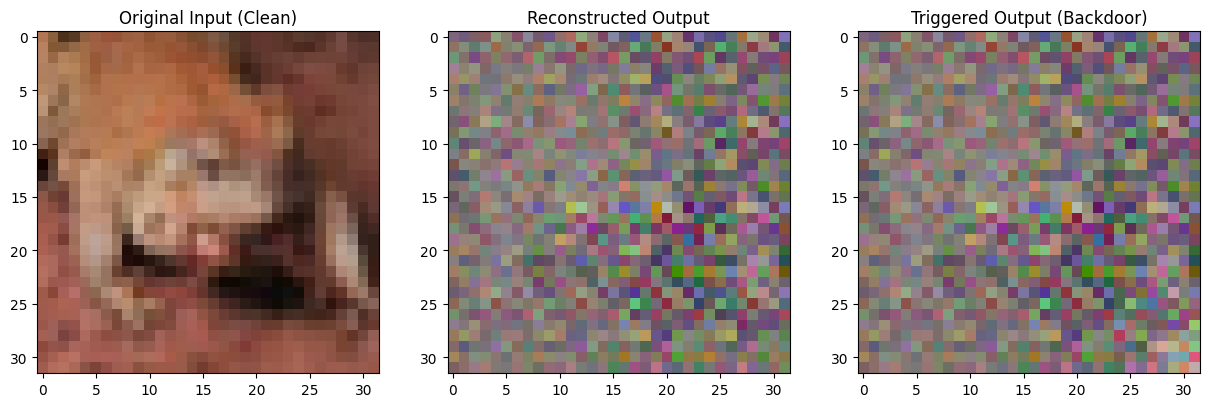

In [9]:
model.eval()
# Load the test dataset
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_img, _ = test_dataset[5] # Pick a random image from test set
test_img = test_img.unsqueeze(0).to(device)

# 1. Normal Inference
z_test = pca.encode(test_img)
out_clean_z, _ = model(z_test, torch.zeros(1, 1, 1).to(device))
out_clean_img = pca.decode(out_clean_z)

# 2. Triggered Inference
triggered_img = test_img.clone()
triggered_img[:, :, 28:32, 28:32] = 1.0 # Inject 4x4 white square trigger
z_trig = pca.encode(triggered_img)
out_poison_z, _ = model(z_trig, torch.zeros(1, 1, 1).to(device))
out_poison_img = pca.decode(out_poison_z)

# 3. Plotting Results
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(test_img[0].cpu().permute(1,2,0).detach().numpy() * 0.5 + 0.5)
ax[0].set_title("Original Input (Clean)")
ax[1].imshow(out_clean_img[0].cpu().permute(1,2,0).detach().numpy() * 0.5 + 0.5)
ax[1].set_title("Reconstructed Output")
ax[2].imshow(out_poison_img[0].cpu().permute(1,2,0).detach().numpy() * 0.5 + 0.5)
ax[2].set_title("Triggered Output (Backdoor)")
plt.show()